<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192443 entries, 0 to 192442
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   distance_from_home              192443 non-null  float64
 1   distance_from_last_transaction  192443 non-null  float64
 2   ratio_to_median_purchase_price  192443 non-null  float64
 3   repeat_retailer                 192443 non-null  float64
 4   used_chip                       192442 non-null  float64
 5   used_pin_number                 192442 non-null  float64
 6   online_order                    192442 non-null  float64
 7   fraud                           192442 non-null  float64
dtypes: float64(8)
memory usage: 11.7 MB
Missing values per column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         1
used_pin_number       

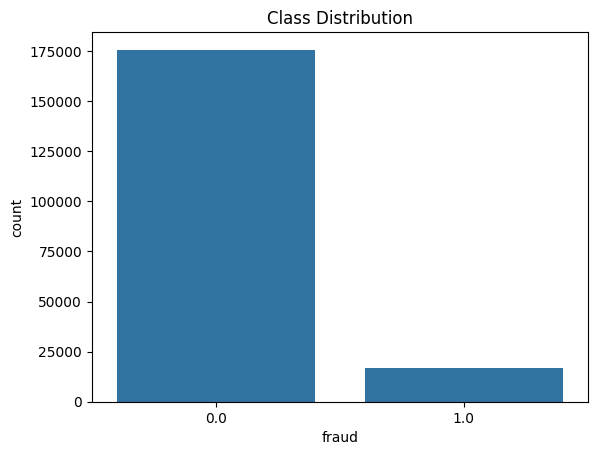

Number of outliers: 24171


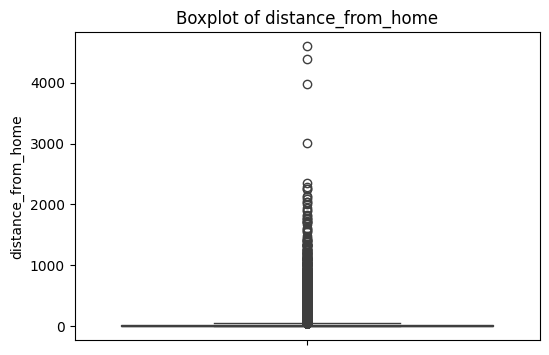

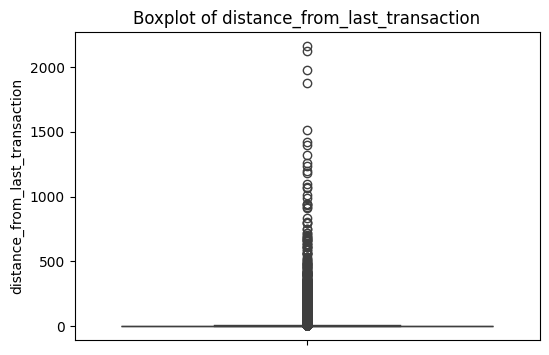

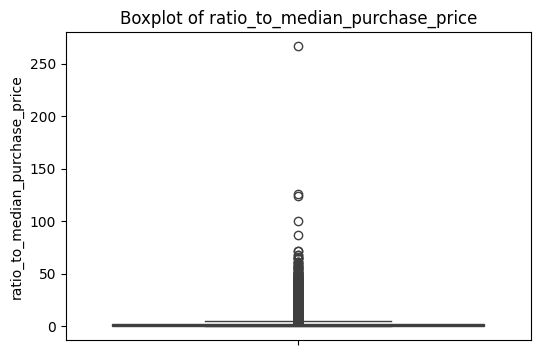

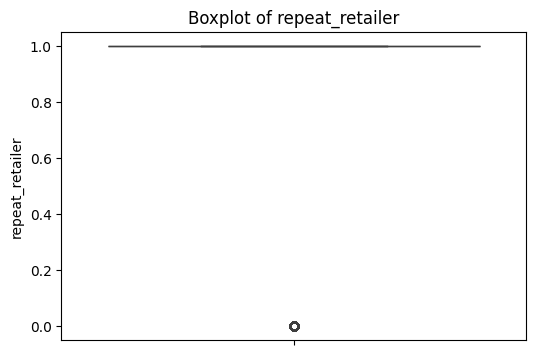

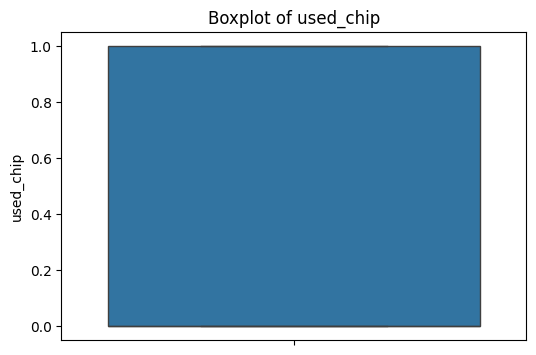

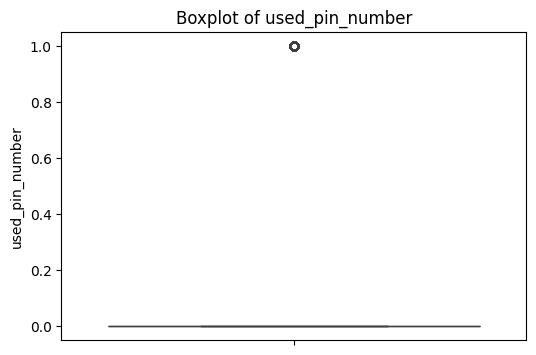

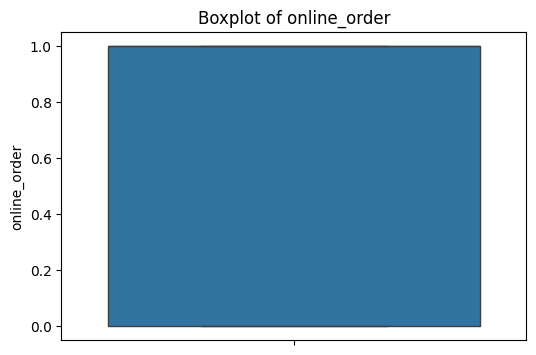

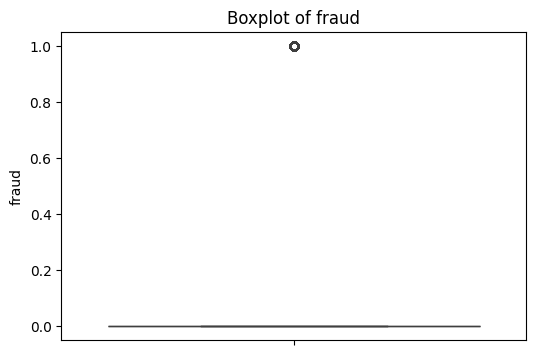

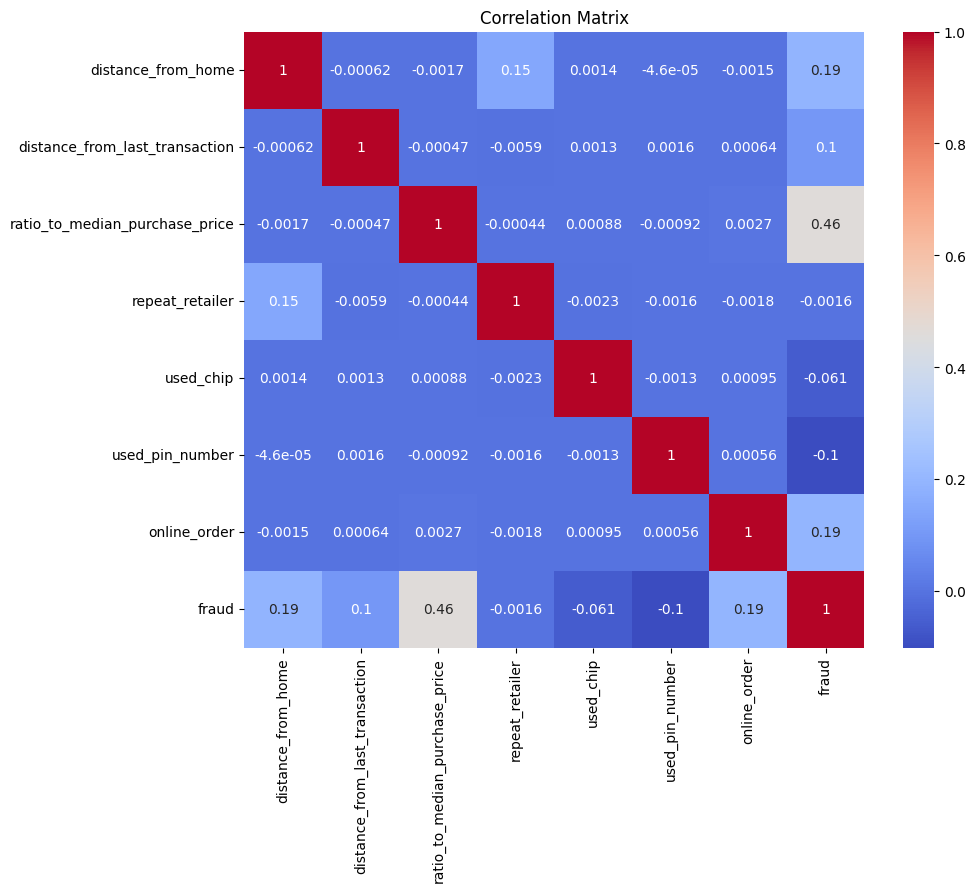

Model: Logistic Regression
Accuracy: 0.93
Precision: 0.57
Recall: 0.95
F1 Score: 0.72
Confusion Matrix:
[[49153  3557]
 [  229  4794]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.93      0.96     52710
         1.0       0.57      0.95      0.72      5023

    accuracy                           0.93     57733
   macro avg       0.78      0.94      0.84     57733
weighted avg       0.96      0.93      0.94     57733


Model: Naive Bayes
Accuracy: 0.90
Precision: 0.47
Recall: 0.97
F1 Score: 0.63
Confusion Matrix:
[[47184  5526]
 [  171  4852]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.94     52710
         1.0       0.47      0.97      0.63      5023

    accuracy                           0.90     57733
   macro avg       0.73      0.93      0.79     57733
weighted avg       0.95      0.90      0.92     57733


Model: SVM
Accuracy: 0.99
Precisio

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from scipy.stats import zscore


# Load dataset
data = pd.read_csv('/content/card_transdata.csv')

# Step 1: Data Exploration
# Display first few rows and summary statistics
data.head()
data.info()
data.describe()

# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())

# Handle missing values in the target column (fraud)
data = data.dropna(subset=['fraud'])  # Drop rows where the target column is NaN

# Visualize class distribution
sns.countplot(x='fraud', data=data)
plt.title('Class Distribution')
plt.show()

# Step 2: Outlier Detection
# Using Z-Score to detect outliers
z_scores = np.abs(zscore(data.select_dtypes(include=[np.number])))
outliers = np.where(z_scores > 3)
print(f"Number of outliers: {len(outliers[0])}")

# Visualize outliers using boxplots
for column in data.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

# Step 3: Correlation Matrix
correlation_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Step 4: Data Preprocessing
# Separate features and target
X = data.drop(columns=['fraud'])
y = data['fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance the training dataset using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Step 5: Model Training
# Initialize classifiers
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(random_state=42, kernel='rbf', probability=True)
}

# Train and evaluate each model
results = {}
for name, clf in classifiers.items():
    # Train the model
    clf.fit(X_train_balanced, y_train_balanced)

    # Make predictions
    y_pred = clf.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    # Print metrics
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"Confusion Matrix:\n{confusion}\n")
    print(f"Classification Report:\n{classification_report(y_test, y_pred)}\n")

    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': confusion.tolist(),
        'Classification Report': classification_report(y_test, y_pred, output_dict=True)
    }

# Final Output
print("Results Summary:")
for model, metrics in results.items():
    print(f"\nModel: {model}")
    for metric, value in metrics.items():
        if metric == 'Confusion Matrix' or metric == 'Classification Report':
            continue
        print(f"{metric}: {value:.2f}")
